# Energy regression on the hadron runs — XGBoost

**Goal:** given a single detector event, predict the beam energy of the run it
came from. We use only the **hadron 4xx runs** (`particle == "h"`, runs 445-459), which span eight beam energies:

| run | 445 | 446 | 448 | 450 | 451 | 452 | 458 | 459 |
|-----|-----|-----|-----|-----|-----|-----|-----|-----|
| E [GeV] | 150 | 200 | 300 | 100 | 80 | 60 | 250 | 350 |

Same data pipeline as `CNN_Regression_hadron_energy.ipynb` and
`MLP_Regression_hadron_energy.ipynb` (identical ROOT loading and per-run pedestal
normalization), but the model is a **gradient-boosted tree ensemble** (XGBoost)
instead of a neural net. The `(2, 64, 38)` event is flattened to a 4864-feature
vector and each feature is treated as an independent input column — like the MLP,
the tree model has no notion of spatial locality.

In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import uproot
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


def find_project_root(marker="Data", start=None):
    """Walk up from `start` (default: cwd) until we find a directory containing `marker`."""
    p = (start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).is_dir():
            return candidate
    raise FileNotFoundError(f"Could not find '{marker}' starting from {p}")

PROJECT_ROOT = find_project_root("Data")
DATA_DIR     = PROJECT_ROOT / "Data"
LABELS_CSV   = DATA_DIR / "runs.csv"
print("project root:", PROJECT_ROOT)


project root: /Users/prometheus/Documents/Python/ML_FoCal_FinalProject


In [2]:
# data loading
labels_df = pd.read_csv(LABELS_CSV)
# Keep only the hadron 4xx runs (energy scan at bias 0).
runs_df = labels_df.query("particle == 'h' and 400 <= run < 500").sort_values("energy_GeV").copy()
print("runs to load:")
print(runs_df.to_string(index=False))

def find_root_file(run, data_dir=DATA_DIR):
    """Match either RunXXXX.root or RunXXX_EventMatch.root naming."""
    candidates = list(data_dir.glob(f"Run{run}*.root")) + list(data_dir.glob(f"Run{run:04d}*.root"))
    if not candidates:
        raise FileNotFoundError(f"No ROOT file for run {run}")
    return candidates[0]

# Pre-count entries so we can preallocate (raw kept as uint16 to halve memory:
# ADC values are in 0..1023, which fits comfortably).
counts = {}
for _, row in runs_df.iterrows():
    t = uproot.open(find_root_file(int(row["run"])))["data_tree"]
    counts[int(row["run"])] = t.num_entries
N_total = sum(counts.values())
print(f"\ntotal events to load: {N_total}")

val0    = np.empty((N_total, 2, 64, 38), dtype=np.uint16)
run_id  = np.empty(N_total, dtype=np.int32)
energy  = np.empty(N_total, dtype=np.float32)   # beam energy in GeV (regression target)

pos = 0
for _, row in runs_df.iterrows():
    run, E = int(row["run"]), float(row["energy_GeV"])
    t = uproot.open(find_root_file(run))["data_tree"]
    n = t.num_entries
    a0 = t["val0_list_0"].array(library="np").reshape(-1, 64, 38)
    a1 = t["val0_list_1"].array(library="np").reshape(-1, 64, 38)
    val0[pos:pos + n]   = np.stack([a0, a1], axis=1).astype(np.uint16)
    run_id[pos:pos + n] = run
    energy[pos:pos + n] = E
    pos += n
    print(f"  Run{run:04d}: {n:6d} events  ({E:.0f} GeV)")

assert pos == N_total
print(f"\nloaded val0: shape={val0.shape}  dtype={val0.dtype}  ({val0.nbytes / 1e9:.2f} GB)")

runs to load:
 run  energy_GeV particle  bias_V
 452          60        h       0
 451          80        h       0
 450         100        h       0
 445         150        h       0
 446         200        h       0
 458         250        h       0
 448         300        h       0
 459         350        h       0

total events to load: 274465
  Run0452:  37338 events  (60 GeV)
  Run0451:  34088 events  (80 GeV)
  Run0450:  32905 events  (100 GeV)
  Run0445:  32969 events  (150 GeV)
  Run0446:  33434 events  (200 GeV)
  Run0458:  35122 events  (250 GeV)
  Run0448:  34683 events  (300 GeV)
  Run0459:  33926 events  (350 GeV)

loaded val0: shape=(274465, 2, 64, 38)  dtype=uint16  (2.67 GB)


### Data shape

Loaded as `val0` with shape `(N, 2, 64, 38)`:

| Dim | Size | Meaning |
|-----|------|---------|
| 0   | N    | event index (one event = one trigger) |
| 1   | 2    | detector halves: `h0`, `h1` |
| 2   | 64   | chips per half |
| 3   | 38   | readout channels per chip |

Parallel label arrays of length N: `run_id` and `energy` (the GeV value we
regress on).

val0 shape: (274465, 2, 64, 38)  dtype: uint16
value range: 0 .. 1023
mean: 114.7  nonzero fraction: 0.968

events per energy:
            n_events  run
energy_GeV               
60.0           37338  452
80.0           34088  451
100.0          32905  450
150.0          32969  445
200.0          33434  446
250.0          35122  458
300.0          34683  448
350.0          33926  459


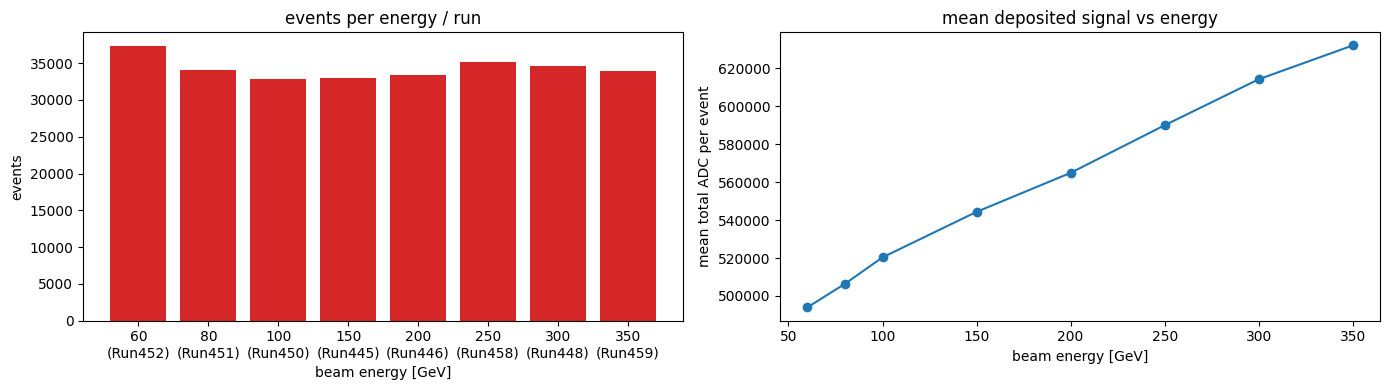

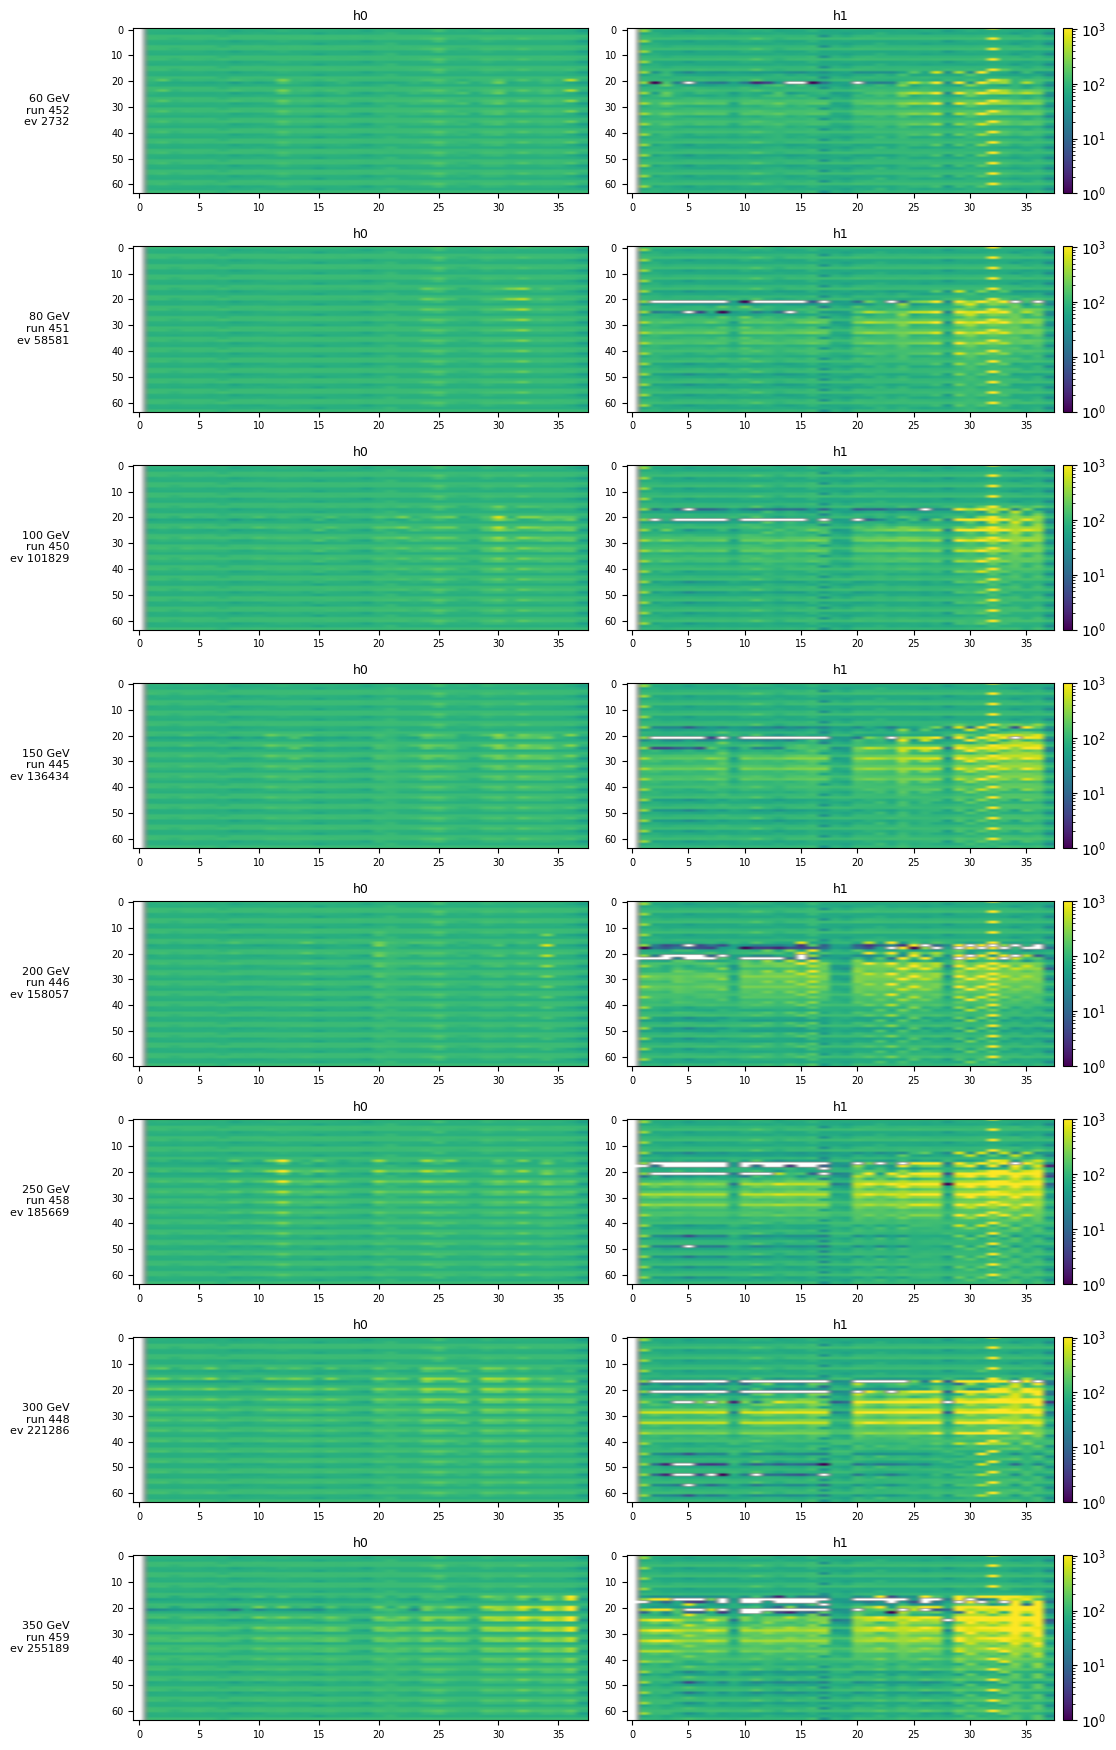

In [3]:
# Visualisation of the data (counts and example events)
print(f"val0 shape: {val0.shape}  dtype: {val0.dtype}")
print(f"value range: {val0.min()} .. {val0.max()}")
print(f"mean: {val0.mean():.1f}  nonzero fraction: {(val0 > 0).mean():.3f}")

summary = (pd.DataFrame({"run": run_id, "energy_GeV": energy})
           .groupby("energy_GeV").agg(n_events=("run", "size"), run=("run", "first")))
print("\nevents per energy:")
print(summary)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar([f"{int(E)}\n(Run{int(r)})" for E, r in zip(summary.index, summary.run)],
          summary.n_events, color="#d62728")
ax[0].set_ylabel("events"); ax[0].set_xlabel("beam energy [GeV]")
ax[0].set_title("events per energy / run")

# Mean total ADC per event vs energy -- the simplest physics sanity check:
# a calorimeter should deposit more signal at higher energy.
event_sum = val0.sum(axis=(1, 2, 3), dtype=np.int64)
mean_sum  = [event_sum[energy == E].mean() for E in summary.index]
ax[1].plot(summary.index, mean_sum, "o-", color="#1f77b4")
ax[1].set_xlabel("beam energy [GeV]"); ax[1].set_ylabel("mean total ADC per event")
ax[1].set_title("mean deposited signal vs energy")
plt.tight_layout(); plt.show()

# One example event per energy -- both halves
from matplotlib.colors import LogNorm
energies_sorted = np.array(sorted(np.unique(energy)))
fig, ax = plt.subplots(len(energies_sorted), 2, figsize=(11, 2.2 * len(energies_sorted)), squeeze=False)
rng = np.random.RandomState(0)
for gi, E in enumerate(energies_sorted):
    idx = rng.choice(np.where(energy == E)[0])
    ev  = val0[idx]
    vmax = max(int(np.percentile(ev, 99.5)), 2)
    for h in range(2):
        im = ax[gi, h].imshow(ev[h], aspect="auto", cmap="viridis",
                              norm=LogNorm(vmin=1, vmax=vmax))
        ax[gi, h].set_title(f"h{h}", fontsize=9)
        ax[gi, h].tick_params(labelsize=7)
    plt.colorbar(im, ax=ax[gi, 1], fraction=0.04, pad=0.02)
    ax[gi, 0].set_ylabel(f"{int(E)} GeV\nrun {run_id[idx]}\nev {idx}",
                         rotation=0, ha="right", va="center", labelpad=30, fontsize=8)
plt.tight_layout(); plt.subplots_adjust(left=0.10); plt.show()

### Per-run pedestal normalization

For each **run**, take the quietest 50% of events by total ADC — mostly
noise/pedestal events where the hadron deposited little — and use them to
compute a per-channel mean and std. Then z-score every event of that run.


In [4]:
""" Pedestal normalization, computed separately per run.
For each run, the quietest 50% of events (lowest total ADC) define the
per-channel pedestal mean/std; all events of that run are z-scored by them.
"""

event_sum = val0.sum(axis=(1, 2, 3), dtype=np.int64)

pedestals = {}  # run -> (mean (2,64,38), std (2,64,38))
for r in np.unique(run_id):
    in_run = run_id == r
    cutoff = np.percentile(event_sum[in_run], 50)
    quiet  = in_run & (event_sum < cutoff)
    mean   = val0[quiet].mean(axis=0).astype(np.float32)
    std    = val0[quiet].std(axis=0).astype(np.float32)
    pedestals[int(r)] = (mean, std)
    print(f"Run{r:04d}: {quiet.sum():6d} quiet events used  "
          f"mean ADC {mean.min():.1f}..{mean.max():.1f}  avg std {std.mean():.2f}")

# Apply normalization in place per-run slice (avoids a second full-size copy)
val0_norm = np.empty(val0.shape, dtype=np.float32)
for r, (mean, std) in pedestals.items():
    m = run_id == r
    val0_norm[m] = (val0[m].astype(np.float32) - mean) / (std + 1e-3)

print(f"\nnormalized: shape={val0_norm.shape}  dtype={val0_norm.dtype}  "
      f"memory={val0_norm.nbytes / 1e9:.2f} GB")
print(f"mean: {val0_norm.mean():+.3f}  (should be ~0 since most events are quiet)")
print(f"std : {val0_norm.std():.3f}  (close to 1 if normalization is sane)")

Run0445:  16482 quiet events used  mean ADC 0.0..1023.0  avg std 29.56
Run0446:  16717 quiet events used  mean ADC 0.0..1023.0  avg std 34.42
Run0448:  17341 quiet events used  mean ADC 0.0..1023.0  avg std 41.84
Run0450:  16452 quiet events used  mean ADC 0.0..1023.0  avg std 20.33
Run0451:  17042 quiet events used  mean ADC 0.0..1023.0  avg std 17.49
Run0452:  18669 quiet events used  mean ADC 0.0..1023.0  avg std 14.22
Run0458:  17559 quiet events used  mean ADC 0.0..1023.0  avg std 38.63
Run0459:  16963 quiet events used  mean ADC 0.0..1023.0  avg std 45.14

normalized: shape=(274465, 2, 64, 38)  dtype=float32  memory=5.34 GB
mean: +0.046  (should be ~0 since most events are quiet)
std : 1.064  (close to 1 if normalization is sane)


### Building the regression dataset

**Input:** the two pedestal-normalized detector halves, flattened from
`(N, 2, 64, 38)` to a `(N, 4864)` feature matrix — one column per
channel/chip/strip. Trees split on individual features, so the flat layout is
the natural input; spatial structure is discarded (same as the MLP).

**Target:** beam energy in GeV. Trees are invariant to monotonic rescaling for a
plain squared-error loss, **but** the pseudo-Huber objective has a fixed
transition point (`huber_slope`, default 1.0) measured in target units. On raw
GeV (60–350) almost every residual would fall in the linear regime and the model
would barely learn — so we standardize the target on the **train split only**
(`y_norm = (E - mean) / std`, exactly as the NN notebooks do) and invert back to
GeV for every reported metric.

**Splits**, all stratified on energy so each of the 8 energies appears in the
same proportion in every split:
- **train (70%)** — fit the trees
- **val (15%)** — early stopping (watch val MAE, stop when it stops improving)
- **test (15%)** — final per-event evaluation, looked at exactly once

In [5]:
# Flatten the 2-channel input to a feature matrix for XGBoost.
X     = val0_norm.reshape(len(val0_norm), -1).astype(np.float32)  # (N, 4864)
y_gev = energy.astype(np.float32)

print(f"X: {X.shape}  {X.nbytes / 1e9:.2f} GB")
print(f"y: {y_gev.shape}  energies: {sorted(np.unique(y_gev).astype(int).tolist())}")

# Stratify on energy so every split has all 8 energies in proportion
strat = energy.astype(int).astype(str)

idx_trainval, idx_test = train_test_split(
    np.arange(len(X)), test_size=0.15, stratify=strat, random_state=0)
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=0.15 / 0.85, stratify=strat[idx_trainval], random_state=0)
print(f"\nsplit sizes:  train {len(idx_train)}  val {len(idx_val)}  test {len(idx_test)}")

# Standardize the target on TRAIN statistics only (keeps the pseudo-Huber
# transition well-scaled); invert with Y_STD/Y_MEAN for all reported metrics.
Y_MEAN = float(y_gev[idx_train].mean())
Y_STD  = float(y_gev[idx_train].std())
print(f"target standardization (train):  mean={Y_MEAN:.2f} GeV  std={Y_STD:.2f} GeV")
y_norm = (y_gev - Y_MEAN) / Y_STD

X_train, y_train = X[idx_train], y_norm[idx_train]
X_val,   y_val   = X[idx_val],   y_norm[idx_val]
X_test,  y_test  = X[idx_test],  y_norm[idx_test]


X: (274465, 4864)  5.34 GB
y: (274465,)  energies: [60, 80, 100, 150, 200, 250, 300, 350]

split sizes:  train 192125  val 41170  test 41170
target standardization (train):  mean=185.63 GeV  std=100.56 GeV


### XGBoost regressor configuration

A gradient-boosted tree ensemble: each tree corrects the residuals of the ones
before it. Knobs that matter here:

- **`objective="reg:pseudohubererror"`** — the tree analogue of the neural net's
  `HuberLoss`: quadratic for small residuals, linear for large ones, so a few
  pathological events (showers that mostly missed the detector) don't dominate.
  It acts on the standardized target, so the default transition point is sensible.
- **`n_estimators=2000` + `early_stopping_rounds=30`** — boost up to 2000 rounds
  but stop once val MAE hasn't improved for 30, and keep the best iteration.
- **`learning_rate=0.05`** — small steps, more (but better-regularized) trees.
- **`subsample` / `colsample_bytree`** — row and column subsampling. With 4864
  mostly-quiet features, sampling half the columns per tree fights overfitting
  and speeds training.
- **`max_depth=6`, `min_child_weight=5`, `reg_lambda`** — standard complexity
  control.

In [6]:
reg = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.5,
    min_child_weight=5,
    reg_lambda=1.0,
    objective="reg:pseudohubererror",
    eval_metric="mae",
    early_stopping_rounds=30,
    tree_method="hist",
    n_jobs=-1,
    random_state=0,
)
print(reg)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.5, device=None, early_stopping_rounds=30,
             enable_categorical=False, eval_metric='mae', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2000,
             n_jobs=-1, num_parallel_tree=None, ...)


### Training

`fit` on the train split with the val split as the early-stopping watch set.
XGBoost reports val MAE (in standardized units) each round and keeps the best
iteration. The booster is cached to `Rasmus/Regression/XGB_regressor_hadron.json`;
set `RETRAIN = True` to refit from scratch. No test-set access here.

In [7]:
RETRAIN = False
REGRESSOR_WEIGHTS = PROJECT_ROOT / "Rasmus" / "Regression" / "XGB_regressor_hadron.json"

history = None  # filled with evals_result() when we actually train

if REGRESSOR_WEIGHTS.exists() and not RETRAIN:
    reg.load_model(REGRESSOR_WEIGHTS)
    print(f"loaded cached model from {REGRESSOR_WEIGHTS.name} (set RETRAIN=True to override)")
else:
    reg.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=50,
    )
    history = reg.evals_result()
    reg.save_model(REGRESSOR_WEIGHTS)
    print(f"\nbest iteration: {reg.best_iteration}  "
          f"best val MAE: {reg.best_score * Y_STD:.2f} GeV")
    print(f"saved {REGRESSOR_WEIGHTS}")


loaded cached model from XGB_regressor_hadron.json (set RETRAIN=True to override)


### Validation evaluation

The standard regression diagnostics:

- **Predicted vs true** scatter (with the ideal `y = x` line). 
- **Residuals vs true energy** — reveals systematic bias (does the model
  under-predict high energies and over-predict low ones, the classic
  regression-to-the-mean pull?).
- **Per-energy summary:** mean prediction, bias, and resolution `σ/E`.
- Headline numbers: **MAE**, **RMSE** (both GeV), and **R²**.

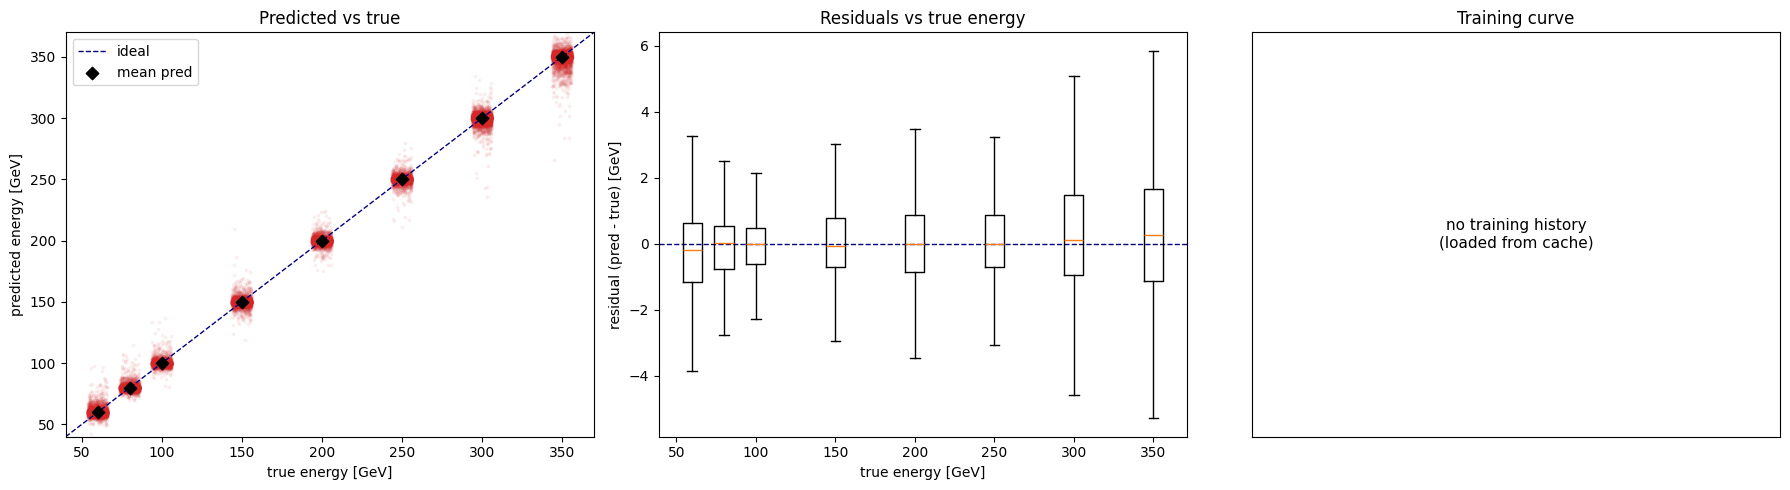

val MAE :    1.78 GeV
val RMSE:    3.44 GeV
val R^2 :  0.9988

per-energy summary:
   E[GeV]      n  mean pred     bias     std  sigma/E
       60   5601       60.1     +0.1     3.0    0.051
       80   5113       80.1     +0.1     2.5    0.031
      100   4936      100.1     +0.1     2.5    0.025
      150   4946      150.0     +0.0     3.1    0.021
      200   5015      200.0     -0.0     2.7    0.013
      250   5268      250.1     +0.1     2.9    0.012
      300   5202      299.8     -0.2     4.2    0.014
      350   5089      349.5     -0.5     5.5    0.016


In [8]:
"""Validation diagnostics for the regressor (everything reported in GeV)."""

y_true = y_gev[idx_val]
y_pred = reg.predict(X_val) * Y_STD + Y_MEAN

mae  = np.mean(np.abs(y_pred - y_true))
rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
r2   = r2_score(y_true, y_pred)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# --- predicted vs true ---
lo, hi = y_true.min() - 20, y_true.max() + 20
ax[0].plot([lo, hi], [lo, hi], "--", color="navy", lw=1, label="ideal")
ax[0].scatter(y_true + np.random.uniform(-6, 6, len(y_true)), y_pred,
              s=3, alpha=0.05, color="#d62728")
energies_sorted = np.array(sorted(np.unique(y_true)))
ax[0].scatter(energies_sorted, [y_pred[y_true == E].mean() for E in energies_sorted],
              color="black", marker="D", s=40, zorder=5, label="mean pred")
ax[0].set_xlabel("true energy [GeV]"); ax[0].set_ylabel("predicted energy [GeV]")
ax[0].set_title("Predicted vs true"); ax[0].legend(loc="upper left")
ax[0].set_xlim(lo, hi); ax[0].set_ylim(lo, hi)

# --- residuals vs true ---
resid = y_pred - y_true
ax[1].axhline(0, color="navy", ls="--", lw=1)
parts = [resid[y_true == E] for E in energies_sorted]
ax[1].boxplot(parts, positions=energies_sorted, widths=12, showfliers=False,
              manage_ticks=False)
ax[1].set_xlabel("true energy [GeV]"); ax[1].set_ylabel("residual (pred - true) [GeV]")
ax[1].set_title("Residuals vs true energy")

# --- training curve (val MAE per boosting round, converted to GeV) ---
if history is not None:
    tr = np.array(history["validation_0"]["mae"]) * Y_STD
    va = np.array(history["validation_1"]["mae"]) * Y_STD
    ax[2].plot(tr, label="train MAE", color="#1f77b4")
    ax[2].plot(va, label="val MAE",   color="#ff7f0e")
    ax[2].axvline(reg.best_iteration, color="grey", ls=":", label="best iter")
    ax[2].set_xlabel("boosting round"); ax[2].set_ylabel("MAE [GeV]")
    ax[2].set_title("Training curve"); ax[2].legend(loc="upper right")
else:
    ax[2].text(0.5, 0.5, "no training history\n(loaded from cache)",
               ha="center", va="center", transform=ax[2].transAxes, fontsize=11)
    ax[2].set_xticks([]); ax[2].set_yticks([]); ax[2].set_title("Training curve")

plt.tight_layout(); plt.show()

print(f"val MAE :  {mae:6.2f} GeV")
print(f"val RMSE:  {rmse:6.2f} GeV")
print(f"val R^2 :  {r2:6.4f}")
print("\nper-energy summary:")
print(f"  {'E[GeV]':>7} {'n':>6} {'mean pred':>10} {'bias':>8} {'std':>7} {'sigma/E':>8}")
for E in energies_sorted:
    m = y_true == E
    mp, sd = y_pred[m].mean(), y_pred[m].std()
    print(f"  {int(E):>7} {m.sum():>6} {mp:>10.1f} {mp - E:>+8.1f} {sd:>7.1f} {sd / E:>8.3f}")


### Final test-set evaluation

The held-out 15% test split, never seen during training or model selection. Run
this **once**, at the end. If you change the model based on what you see here,
it stops being a test set.

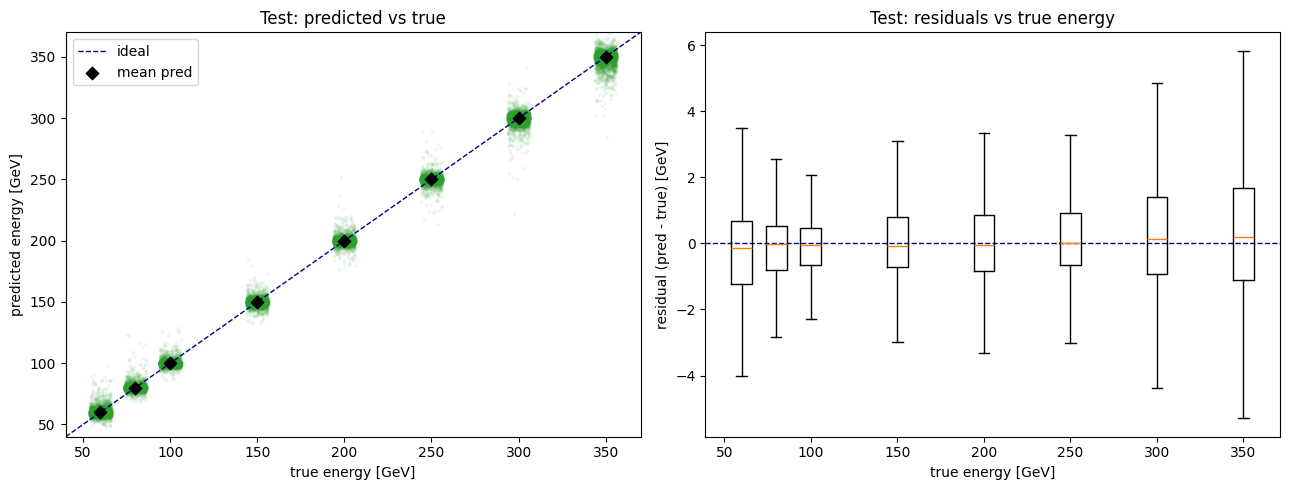

test MAE :    1.77 GeV
test RMSE:    3.39 GeV
test R^2 :  0.9989

per-energy summary:
   E[GeV]      n  mean pred     bias     std  sigma/E
       60   5601       60.1     +0.1     3.1    0.052
       80   5113       80.1     +0.1     2.7    0.034
      100   4936      100.1     +0.1     2.2    0.022
      150   4945      150.0     +0.0     2.7    0.018
      200   5015      200.1     +0.1     2.9    0.015
      250   5268      250.0     +0.0     3.0    0.012
      300   5203      299.8     -0.2     4.2    0.014
      350   5089      349.6     -0.4     5.2    0.015


In [9]:
"""FINAL test-set evaluation -- run once."""

y_true = y_gev[idx_test]
y_pred = reg.predict(X_test) * Y_STD + Y_MEAN

mae  = np.mean(np.abs(y_pred - y_true))
rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
r2   = r2_score(y_true, y_pred)
energies_sorted = np.array(sorted(np.unique(y_true)))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

lo, hi = y_true.min() - 20, y_true.max() + 20
ax[0].plot([lo, hi], [lo, hi], "--", color="navy", lw=1, label="ideal")
ax[0].scatter(y_true + np.random.uniform(-6, 6, len(y_true)), y_pred,
              s=3, alpha=0.05, color="#2ca02c")
ax[0].scatter(energies_sorted, [y_pred[y_true == E].mean() for E in energies_sorted],
              color="black", marker="D", s=40, zorder=5, label="mean pred")
ax[0].set_xlabel("true energy [GeV]"); ax[0].set_ylabel("predicted energy [GeV]")
ax[0].set_title("Test: predicted vs true"); ax[0].legend(loc="upper left")
ax[0].set_xlim(lo, hi); ax[0].set_ylim(lo, hi)

ax[1].axhline(0, color="navy", ls="--", lw=1)
parts = [(y_pred - y_true)[y_true == E] for E in energies_sorted]
ax[1].boxplot(parts, positions=energies_sorted, widths=12, showfliers=False,
              manage_ticks=False)
ax[1].set_xlabel("true energy [GeV]"); ax[1].set_ylabel("residual (pred - true) [GeV]")
ax[1].set_title("Test: residuals vs true energy")
plt.tight_layout(); plt.show()

print(f"test MAE :  {mae:6.2f} GeV")
print(f"test RMSE:  {rmse:6.2f} GeV")
print(f"test R^2 :  {r2:6.4f}")
print("\nper-energy summary:")
print(f"  {'E[GeV]':>7} {'n':>6} {'mean pred':>10} {'bias':>8} {'std':>7} {'sigma/E':>8}")
for E in energies_sorted:
    m = y_true == E
    mp, sd = y_pred[m].mean(), y_pred[m].std()
    print(f"  {int(E):>7} {m.sum():>6} {mp:>10.1f} {mp - E:>+8.1f} {sd:>7.1f} {sd / E:>8.3f}")


### Leave-one-energy-out: did it learn physics or memorize runs?

This is the honest test promised at the top. We **remove one entire energy**
(its whole run) from training, train a fresh model on the other seven, then ask
it to predict the held-out energy.

- If the model learned a genuine, smooth energy response, it should **interpolate**
  — predict the held-out energy roughly correctly even though it never saw it.
- If it merely memorized run fingerprints, it has no fingerprint for the missing
  run and will fall back to predicting something like the mean of the energies
  it *did* see — i.e. it cannot extrapolate/interpolate at all.

This retrains from scratch, so it is **off by default**. Set `RUN_LOEO = True`
and pick `HOLDOUT_E` (an interior energy like 150 or 200 makes the cleanest
interpolation test). Results are not cached.

In [10]:
"""Leave-one-energy-out interpolation test. Off by default (retrains a model)."""

RUN_LOEO  = False      # set True to run
HOLDOUT_E = 150       # GeV to hold out entirely from training

if not RUN_LOEO:
    print("RUN_LOEO is False -- skipping. Set it to True to run the interpolation test.")
else:
    holdout_mask = energy == HOLDOUT_E
    seen_mask    = ~holdout_mask
    seen_idx     = np.where(seen_mask)[0]
    print(f"holding out {int(HOLDOUT_E)} GeV ({holdout_mask.sum()} events); "
          f"training on {seen_mask.sum()} events from {np.unique(energy[seen_mask]).astype(int)}")

    # Standardize the target on the SEEN energies only
    ym, ys = float(y_gev[seen_idx].mean()), float(y_gev[seen_idx].std())
    yn = (y_gev - ym) / ys

    s_strat = energy[seen_idx].astype(int).astype(str)
    s_train, s_val = train_test_split(seen_idx, test_size=0.15,
                                      stratify=s_strat, random_state=0)

    loeo = xgb.XGBRegressor(
        n_estimators=2000, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.5, min_child_weight=5, reg_lambda=1.0,
        objective="reg:pseudohubererror", eval_metric="mae",
        early_stopping_rounds=30, tree_method="hist", n_jobs=-1, random_state=0,
    )
    loeo.fit(
        X[s_train], yn[s_train],
        eval_set=[(X[s_val], yn[s_val])],
        verbose=50,
    )

    pred_holdout  = loeo.predict(X[holdout_mask]) * ys + ym
    seen_energies = np.array(sorted(np.unique(energy[seen_mask])))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(pred_holdout, bins=60, color="#9467bd", alpha=0.8)
    ax.axvline(HOLDOUT_E, color="red", lw=2, label=f"true = {int(HOLDOUT_E)} GeV")
    ax.axvline(pred_holdout.mean(), color="black", ls="--", lw=2,
               label=f"mean pred = {pred_holdout.mean():.0f} GeV")
    for E in seen_energies:
        ax.axvline(E, color="grey", ls=":", lw=0.8)
    ax.set_xlabel("predicted energy [GeV]"); ax.set_ylabel("events")
    ax.set_title(f"Predictions on held-out {int(HOLDOUT_E)} GeV (grey = trained energies)")
    ax.legend(); plt.tight_layout(); plt.show()

    seen_mean = energy[seen_mask].mean()
    print(f"\nheld-out true energy : {HOLDOUT_E:.0f} GeV")
    print(f"mean prediction      : {pred_holdout.mean():.1f} GeV")
    print(f"mean of seen energies: {seen_mean:.1f} GeV  "
          f"(what a pure run-memorizer would default toward)")
    print(f"prediction MAE       : {np.mean(np.abs(pred_holdout - HOLDOUT_E)):.1f} GeV")
    print("\nReading the result: a prediction centred near the true 150 GeV (and far "
          "from the seen-energy mean) is evidence of genuine energy interpolation; a "
          "prediction collapsed onto the seen-energy mean suggests run memorization.")


RUN_LOEO is False -- skipping. Set it to True to run the interpolation test.


holding out 350 GeV (33926 events); training on 240539 events from [ 60  80 100 150 200 250 300]
[0]	validation_0-mae:0.78196
[50]	validation_0-mae:0.05447
[100]	validation_0-mae:0.02680
[150]	validation_0-mae:0.02467
[200]	validation_0-mae:0.02309
[250]	validation_0-mae:0.02214
[300]	validation_0-mae:0.02118
[350]	validation_0-mae:0.02044
[400]	validation_0-mae:0.01992
[450]	validation_0-mae:0.01958
[500]	validation_0-mae:0.01922
[550]	validation_0-mae:0.01896
[600]	validation_0-mae:0.01865
[650]	validation_0-mae:0.01836
[700]	validation_0-mae:0.01820
[750]	validation_0-mae:0.01812
[800]	validation_0-mae:0.01802
[850]	validation_0-mae:0.01790
[900]	validation_0-mae:0.01778
[950]	validation_0-mae:0.01770
[1000]	validation_0-mae:0.01761
[1050]	validation_0-mae:0.01754
[1100]	validation_0-mae:0.01742
[1150]	validation_0-mae:0.01732
[1200]	validation_0-mae:0.01728
[1250]	validation_0-mae:0.01721
[1300]	validation_0-mae:0.01711
[1350]	validation_0-mae:0.01707
[1400]	validation_0-mae:0.0170

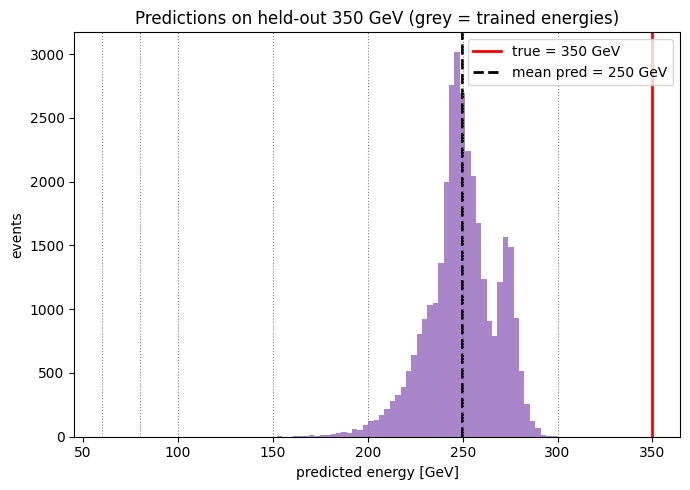


held-out true energy : 350 GeV
mean prediction      : 249.5 GeV
mean of seen energies: 162.4 GeV  (what a pure run-memorizer would default toward)
prediction MAE       : 100.5 GeV

Reading the result: a prediction centred near the true 150 GeV (and far from the seen-energy mean) is evidence of genuine energy interpolation; a prediction collapsed onto the seen-energy mean suggests run memorization.


In [11]:
"""Leave-one-energy-out interpolation test. Off by default (retrains a model)."""

RUN_LOEO  = True      # set True to run
HOLDOUT_E = 350       # GeV to hold out entirely from training

if not RUN_LOEO:
    print("RUN_LOEO is False -- skipping. Set it to True to run the interpolation test.")
else:
    holdout_mask = energy == HOLDOUT_E
    seen_mask    = ~holdout_mask
    seen_idx     = np.where(seen_mask)[0]
    print(f"holding out {int(HOLDOUT_E)} GeV ({holdout_mask.sum()} events); "
          f"training on {seen_mask.sum()} events from {np.unique(energy[seen_mask]).astype(int)}")

    # Standardize the target on the SEEN energies only
    ym, ys = float(y_gev[seen_idx].mean()), float(y_gev[seen_idx].std())
    yn = (y_gev - ym) / ys

    s_strat = energy[seen_idx].astype(int).astype(str)
    s_train, s_val = train_test_split(seen_idx, test_size=0.15,
                                      stratify=s_strat, random_state=0)

    loeo = xgb.XGBRegressor(
        n_estimators=2000, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.5, min_child_weight=5, reg_lambda=1.0,
        objective="reg:pseudohubererror", eval_metric="mae",
        early_stopping_rounds=30, tree_method="hist", n_jobs=-1, random_state=0,
    )
    loeo.fit(
        X[s_train], yn[s_train],
        eval_set=[(X[s_val], yn[s_val])],
        verbose=50,
    )

    pred_holdout  = loeo.predict(X[holdout_mask]) * ys + ym
    seen_energies = np.array(sorted(np.unique(energy[seen_mask])))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(pred_holdout, bins=60, color="#9467bd", alpha=0.8)
    ax.axvline(HOLDOUT_E, color="red", lw=2, label=f"true = {int(HOLDOUT_E)} GeV")
    ax.axvline(pred_holdout.mean(), color="black", ls="--", lw=2,
               label=f"mean pred = {pred_holdout.mean():.0f} GeV")
    for E in seen_energies:
        ax.axvline(E, color="grey", ls=":", lw=0.8)
    ax.set_xlabel("predicted energy [GeV]"); ax.set_ylabel("events")
    ax.set_title(f"Predictions on held-out {int(HOLDOUT_E)} GeV (grey = trained energies)")
    ax.legend(); plt.tight_layout(); plt.show()

    seen_mean = energy[seen_mask].mean()
    print(f"\nheld-out true energy : {HOLDOUT_E:.0f} GeV")
    print(f"mean prediction      : {pred_holdout.mean():.1f} GeV")
    print(f"mean of seen energies: {seen_mean:.1f} GeV  "
          f"(what a pure run-memorizer would default toward)")
    print(f"prediction MAE       : {np.mean(np.abs(pred_holdout - HOLDOUT_E)):.1f} GeV")
    print("\nReading the result: a prediction centred near the true 150 GeV (and far "
          "from the seen-energy mean) is evidence of genuine energy interpolation; a "
          "prediction collapsed onto the seen-energy mean suggests run memorization.")
